# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [3]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




In [ ]:
# Como a hipótese alternativa busca confirmar se a média da Estratégia B é estritamente maior que a da Estratégia A,
# estamos testando apenas o ganho no desempenho. Por focar exclusivamente em um resultado superior,
# o teste é unilateral à direita.

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [4]:
media_A, var_A = np.mean(amostra_estrategia_A), np.var(amostra_estrategia_A, ddof=1)
media_B, var_B = np.mean(amostra_estrategia_B), np.var(amostra_estrategia_B, ddof=1)

print(f"Estratégia A -> Média: {media_A:.2f} | Variância: {var_A:.2f}")
print(f"Estratégia B -> Média: {media_B:.2f} | Variância: {var_B:.2f}")

Estratégia A -> Média: 71.41 | Variância: 129.27
Estratégia B -> Média: 74.75 | Variância: 110.47


In [ ]:
# A Estratégia B apresenta média ligeiramente superior na amostra gerada, porém com maior variabilidade

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [5]:
se = np.sqrt((var_A / len(amostra_estrategia_A)) + (var_B / len(amostra_estrategia_B)))

z_stat = (media_B - media_A) / se

p_value = stats.norm.sf(z_stat)

print(f"Estatística Z: {z_stat:.4f}")
print(f"P-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos a hipótese nula (H0): Há evidências de que a Estratégia B é superior.")
else:
    print("Não rejeitamos a hipótese nula (H0): Não há evidências suficientes para afirmar a superioridade da Estratégia B.")

Estatística Z: 1.5267
P-valor: 0.0634
Não rejeitamos a hipótese nula (H0): Não há evidências suficientes para afirmar a superioridade da Estratégia B.


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

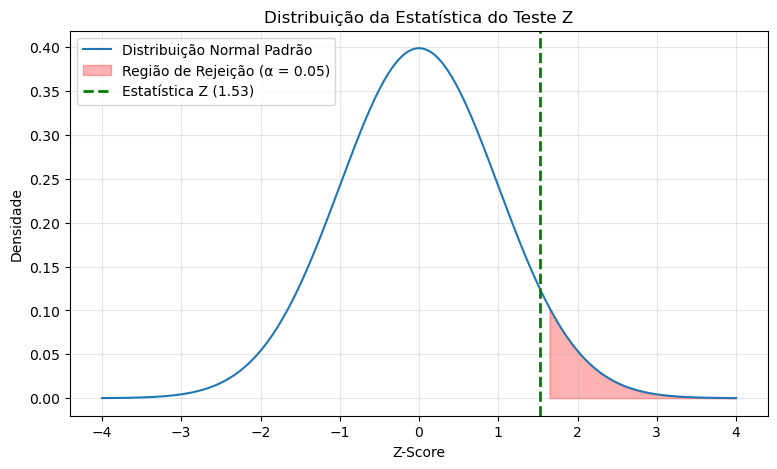

In [7]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(9, 5))
plt.plot(x, y, label='Distribuição Normal Padrão')

# Região de rejeição 
z_critico = stats.norm.ppf(0.95)
plt.fill_between(x, y, where=(x >= z_critico), color='red', alpha=0.3, label='Região de Rejeição (α = 0.05)')
plt.axvline(z_stat, color='green', linestyle='--', linewidth=2, label=f'Estatística Z ({z_stat:.2f})')

plt.title('Distribuição da Estatística do Teste Z')
plt.xlabel('Z-Score')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()